# Plot benchmark results from existing CSV files

This notebook loads the CSV files produced by the benchmark and generates:

- a compact quantitative table for the three paper scenarios
- three grouped barplots for class retention:
  - Day-Rain
  - Sunset-Foggy
  - Night-Rain

It assumes the benchmark has already been run and the CSV files are available on disk.

The notebook is configured for the full set of models:
- SegFormer-B0 / B2 / B5
- Mask2Former-Swin-S / Swin-L
- DeepLabV3+-R101
- PIDNet-M
- DDRNet-23


In [1]:
from pathlib import Path

# ==== USER CONFIG ====
RESULTS_DIR = Path("./out_cityscapes_final_notebook")   # folder containing the CSV outputs
SAVE_DIR = RESULTS_DIR / "notebook_plots"

PLOT_SCENARIOS = ["Day-RAIN", "Sunset-FOGGY", "Night-RAIN"]
PLOT_DROP_CLASSNAME = "train"
MASS_COVERAGE = 0.99   # keep classes covering 99% of masked clean mass
TABLE_DECIMALS = 3

MODEL_ORDER = [
    "SegFormer-B0",
    "SegFormer-B2",
    "SegFormer-B5",
    "Mask2Former-Swin-S",
    "Mask2Former-Swin-L",
    "DeepLabV3+-R101",
    "PIDNet-M",
    "DDRNet-23",
]

SAVE_DIR.mkdir(parents=True, exist_ok=True)
print("Results dir:", RESULTS_DIR.resolve())
print("Save dir:", SAVE_DIR.resolve())


Results dir: /home/ace/Downloads/notebooks/out_cityscapes_final_notebook
Save dir: /home/ace/Downloads/notebooks/out_cityscapes_final_notebook/notebook_plots


In [2]:
# Optional dependency install if needed:
# !mamba install pandas matplotlib


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import os

plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 11,
})

plt.rcParams["figure.dpi"] = 140


In [4]:
def select_classes_by_mass_coverage(df_s: pd.DataFrame, coverage: float, drop_class: str = None):
    df = df_s.copy()
    if drop_class is not None:
        df = df[df["class_name"] != drop_class]

    mass_by_class = df.groupby("class_name")["mass_clean_masked"].sum().sort_values(ascending=False)
    total = float(mass_by_class.sum())
    if total < 1e-9:
        return []

    cum = mass_by_class.cumsum() / total
    keep = mass_by_class.index[cum <= coverage].tolist()

    if len(keep) == 0:
        keep = [mass_by_class.index[0]]
    elif cum.iloc[len(keep) - 1] < coverage and len(keep) < len(mass_by_class):
        keep.append(mass_by_class.index[len(keep)])

    return keep


def _ordered_models(models_in_df, preferred_order):
    preferred = [m for m in preferred_order if m in models_in_df]
    others = sorted([m for m in models_in_df if m not in preferred_order])
    return preferred + others


def save_grouped_barplot(
    df_cls_cond: pd.DataFrame,
    scenario: str,
    save_dir: Path,
    mass_coverage: float,
    drop_class: str,
    model_order=None,
):
    df_s = df_cls_cond[df_cls_cond["sec_condition"] == scenario].copy()
    if df_s.empty:
        print(f"[warn] Scenario {scenario} not found.")
        return None

    keep_classes = select_classes_by_mass_coverage(df_s, coverage=mass_coverage, drop_class=drop_class)
    if not keep_classes:
        print(f"[warn] No classes selected for {scenario}.")
        return None

    df_s = df_s[df_s["class_name"].isin(keep_classes)].copy()
    piv = df_s.pivot_table(index="class_name", columns="model", values="retention_masked")
    piv = piv.reindex(keep_classes)

    models = list(piv.columns)
    if model_order is not None:
        models = _ordered_models(models, model_order)
        piv = piv.reindex(columns=models)

    fig = plt.figure(figsize=(15, 6))
    ax = fig.add_subplot(111)

    classes = list(piv.index)
    x = np.arange(len(classes))
    n_models = len(models)
    bar_width = 0.82 / max(n_models, 1)

    for j, m in enumerate(models):
        y = piv[m].values
        ax.bar(
            x + j * bar_width - (n_models - 1) * bar_width / 2,
            y,
            width=bar_width,
            label=m
        )

    ax.set_xticks(x)
    ax.set_xticklabels(classes, rotation=45, ha="right", fontsize=12)
    ax.set_ylabel("Retention", fontsize=14)
    ax.tick_params(axis="y", labelsize=12)
    ax.set_ylim(0.0, 1.0)

    # Legend outside but relatively close to the plot
    ax.legend(
        loc="center left",
        bbox_to_anchor=(1.01, 0.5),
        frameon=True,
        borderaxespad=0.4,
    )

    fig.tight_layout(rect=[0, 0, 0.86, 1])

    plot_dir = save_dir
    plot_dir.mkdir(parents=True, exist_ok=True)

    out_pdf = plot_dir / f"plot_bar_class_retention__{scenario}.pdf"
    out_png = plot_dir / f"plot_bar_class_retention__{scenario}.png"

    fig.savefig(out_pdf, bbox_inches="tight")
    fig.savefig(out_png, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    print("Saved:", out_pdf)
    print("Saved:", out_png)
    return piv


In [5]:
df_cond = pd.read_csv(RESULTS_DIR / "results_pixel_agreement_by_condition.csv")
df_cls_cond = pd.read_csv(RESULTS_DIR / "results_class_retention_by_condition.csv")

print("Condition summary rows:", len(df_cond))
print("Class retention rows:", len(df_cls_cond))
df_cond.head()


Condition summary rows: 64
Class retention rows: 1216


,model,sec_condition,pixel_agreement_masked_mean,n_pairs,conf_threshold
0,SegFormer-B0,Sunset-FOGGY,0.828815,9,0.6
1,SegFormer-B0,Night-EXTRASUNNY,0.674758,12,0.6
2,SegFormer-B0,Day-FOGGY,0.930902,24,0.6
3,SegFormer-B0,Day-RAIN,0.948212,17,0.6
4,SegFormer-B0,Sunset-RAIN,0.932436,12,0.6


In [6]:
table_df = (
    df_cond[df_cond["sec_condition"].isin(PLOT_SCENARIOS)]
    .pivot(index="model", columns="sec_condition", values="pixel_agreement_masked_mean")
    .reindex(columns=PLOT_SCENARIOS)
)

ordered_index = [m for m in MODEL_ORDER if m in table_df.index] + [m for m in table_df.index if m not in MODEL_ORDER]
table_df = table_df.reindex(ordered_index)

table_df = table_df.assign(_avg=table_df.mean(axis=1)).sort_values("_avg", ascending=False).drop(columns="_avg")
table_df_rounded = table_df.round(TABLE_DECIMALS)
table_df_rounded


sec_condition,Day-RAIN,Sunset-FOGGY,Night-RAIN
model,,,
Mask2Former-Swin-L,0.947,0.893,0.760
SegFormer-B5,0.935,0.891,0.633
Mask2Former-Swin-S,0.941,0.889,0.621
SegFormer-B2,0.932,0.896,0.622
SegFormer-B0,0.948,0.829,0.654
DeepLabV3+-R101,0.879,0.797,0.714
PIDNet-M,0.889,0.730,0.501
DDRNet-23,0.790,0.450,0.484


In [7]:
table_out = SAVE_DIR / "paper_quantitative_table.csv"
table_df_rounded.to_csv(table_out)
print("Saved:", table_out)


Saved: out_cityscapes_final_notebook/notebook_plots/paper_quantitative_table.csv


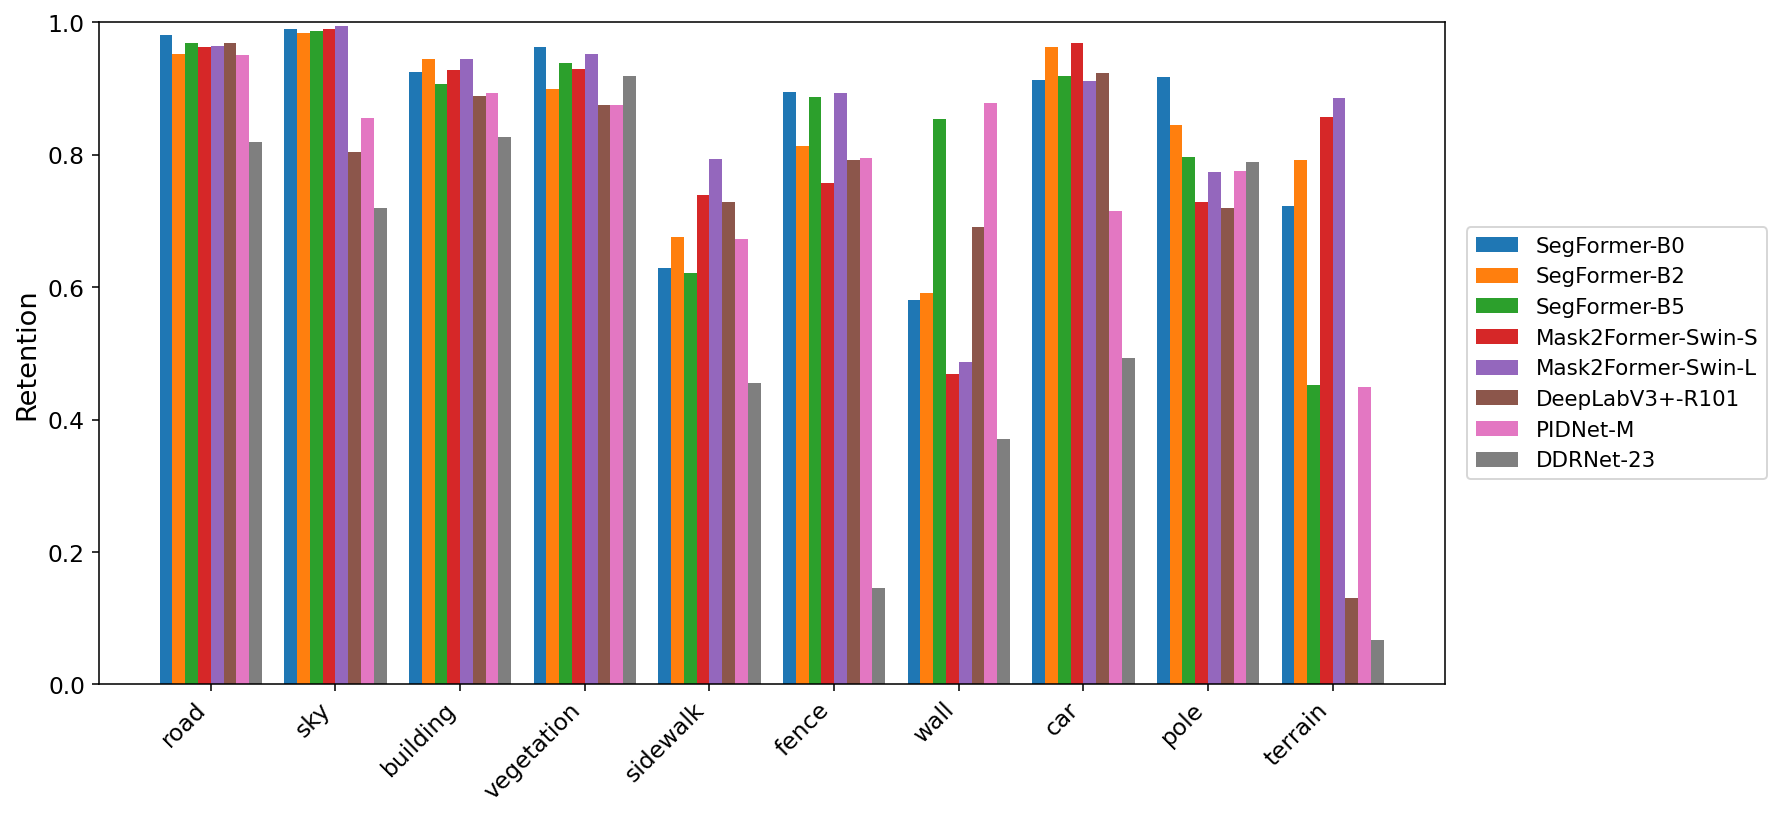

Saved: out_cityscapes_final_notebook/notebook_plots/plot_bar_class_retention__Day-RAIN.pdf
Saved: out_cityscapes_final_notebook/notebook_plots/plot_bar_class_retention__Day-RAIN.png


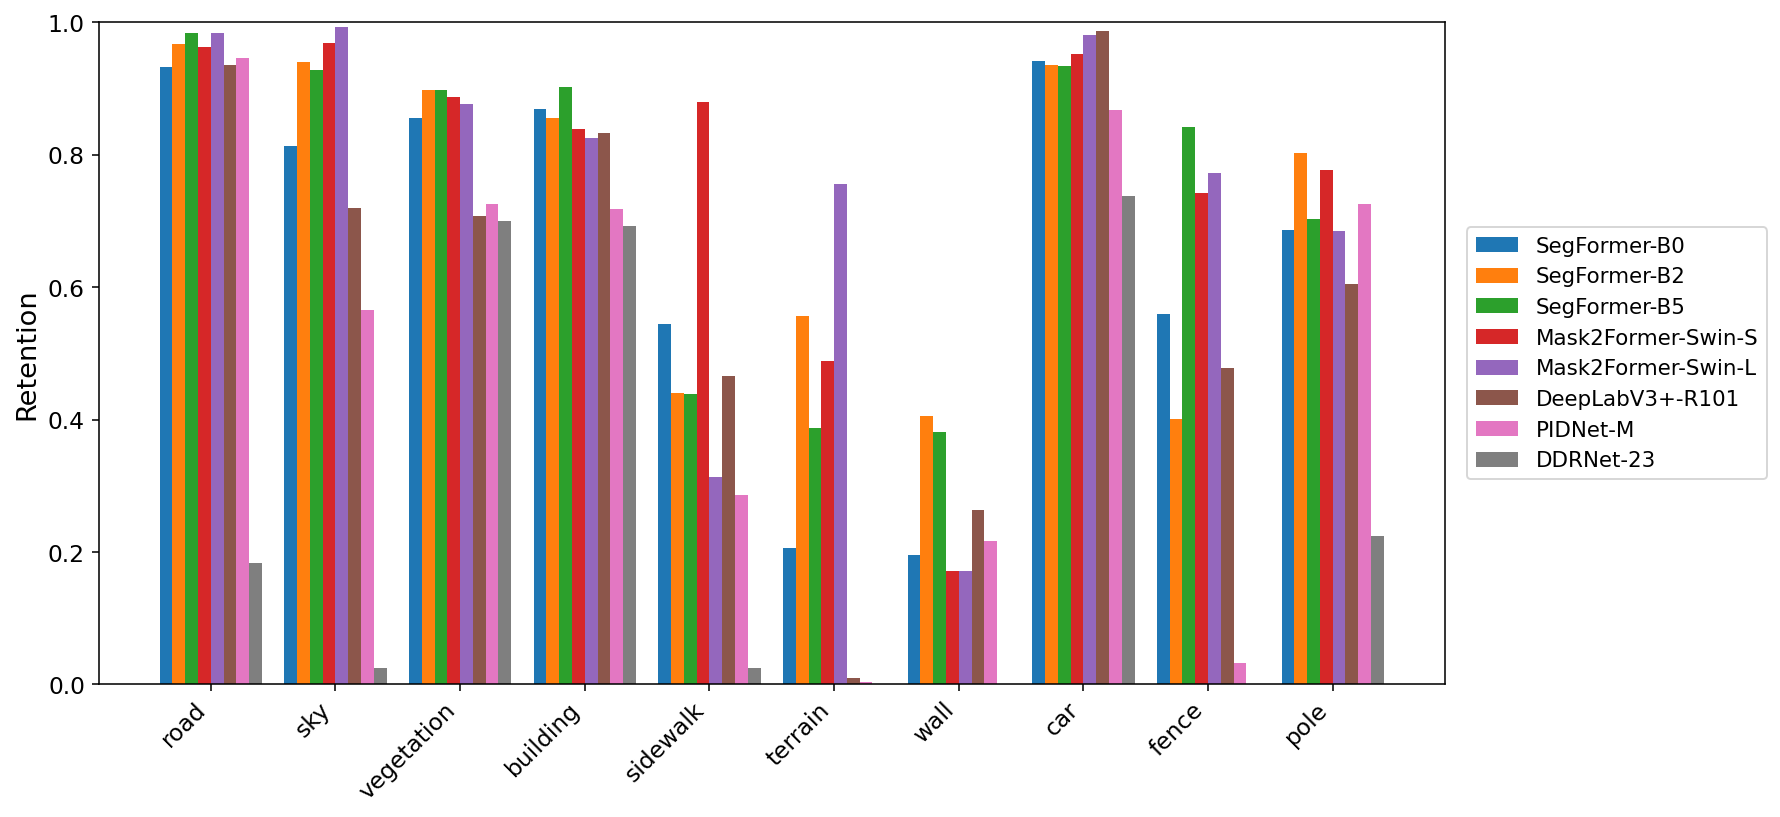

Saved: out_cityscapes_final_notebook/notebook_plots/plot_bar_class_retention__Sunset-FOGGY.pdf
Saved: out_cityscapes_final_notebook/notebook_plots/plot_bar_class_retention__Sunset-FOGGY.png


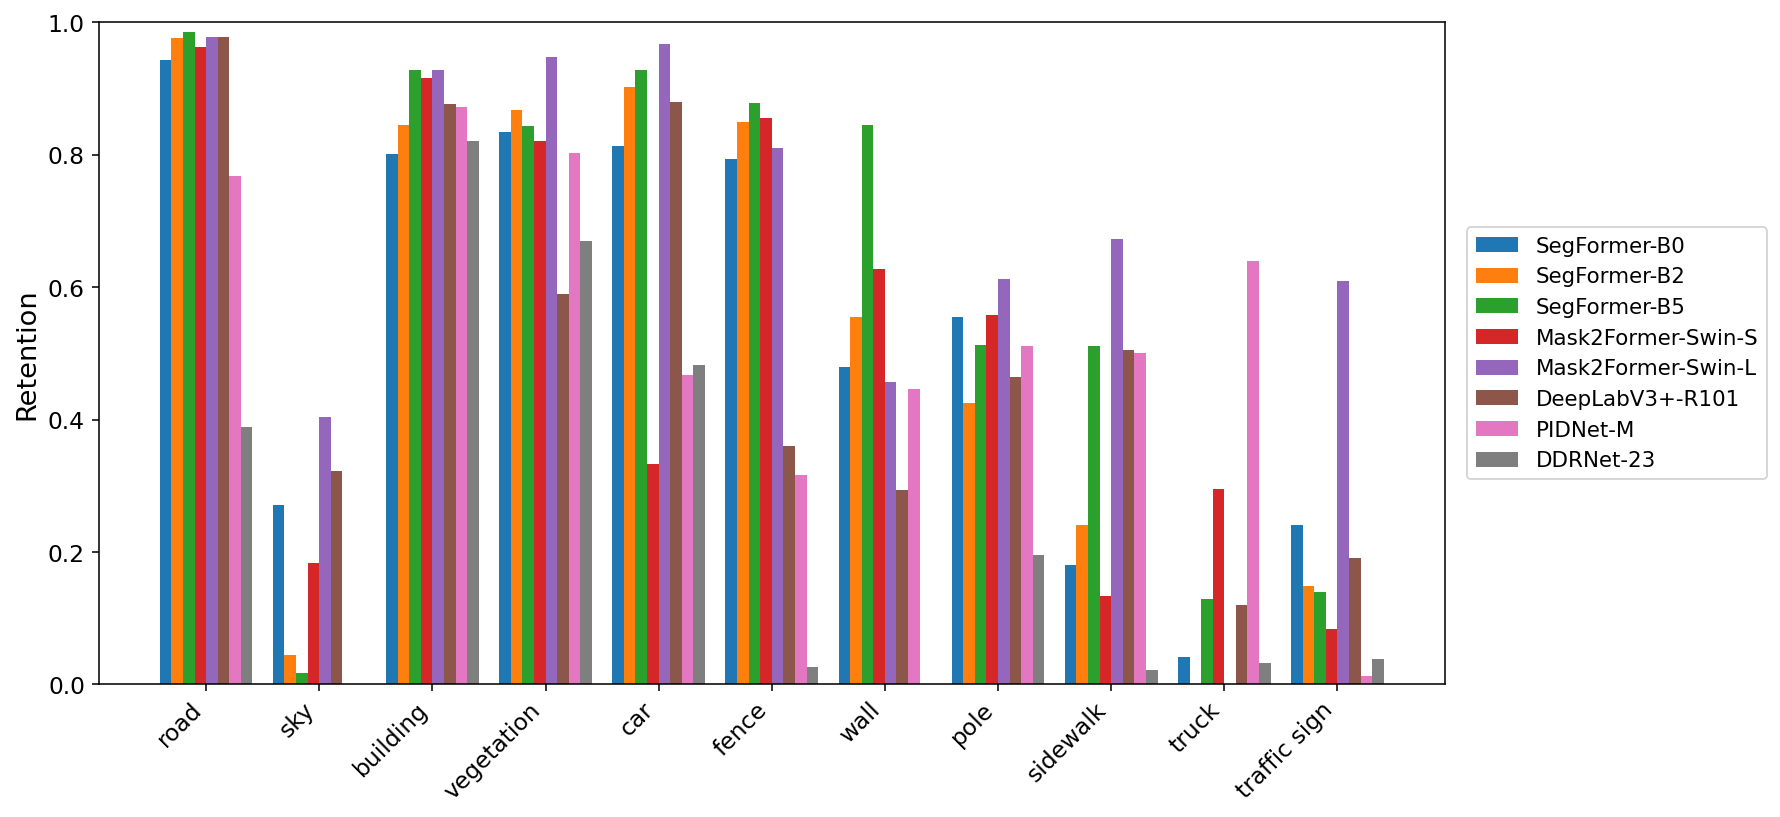

Saved: out_cityscapes_final_notebook/notebook_plots/plot_bar_class_retention__Night-RAIN.pdf
Saved: out_cityscapes_final_notebook/notebook_plots/plot_bar_class_retention__Night-RAIN.png


In [8]:
pivots = {}
for scen in PLOT_SCENARIOS:
    pivots[scen] = save_grouped_barplot(
        df_cls_cond=df_cls_cond,
        scenario=scen,
        save_dir=SAVE_DIR,
        mass_coverage=MASS_COVERAGE,
        drop_class=PLOT_DROP_CLASSNAME,
        model_order=MODEL_ORDER,
    )


## Notes

- `results_pixel_agreement_by_condition.csv` is used for the compact quantitative table.
- `results_class_retention_by_condition.csv` is used for the class-retention barplots.
- The class `train` is removed only from the plots.
- The plotted classes are selected automatically using mass coverage, exactly as in the benchmark script.
- The display order is fixed so the three newly added models also appear consistently:
  - DeepLabV3+-R101
  - PIDNet-M
  - DDRNet-23
